In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
import os


# IMport parent dir
import sys
sys.path.append('..')

from EBM.EBM_models import create_ebm

### EBM Sizes in Terms of Num Parameters

In [57]:
nfs = [48,32,32,128]
for i,model_name in enumerate(['SuperLightEBM','LightEBM','EBM', 'EBMSNGAN32']):
    model = create_ebm(model_name,num_filters=nfs[i])
    print(f'Number of parameters in {model.__class__.__name__} (nf={nfs[i]}): {sum(p.numel() for p in model.parameters())}')

Number of parameters in SuperLightweightEBM (nf=48): 212065
Number of parameters in LightweightEBM (nf=32): 242881
Number of parameters in EBM (nf=32): 693569
Number of parameters in EBMSNGAN32 (nf=128): 1053824


## Compare EBMS

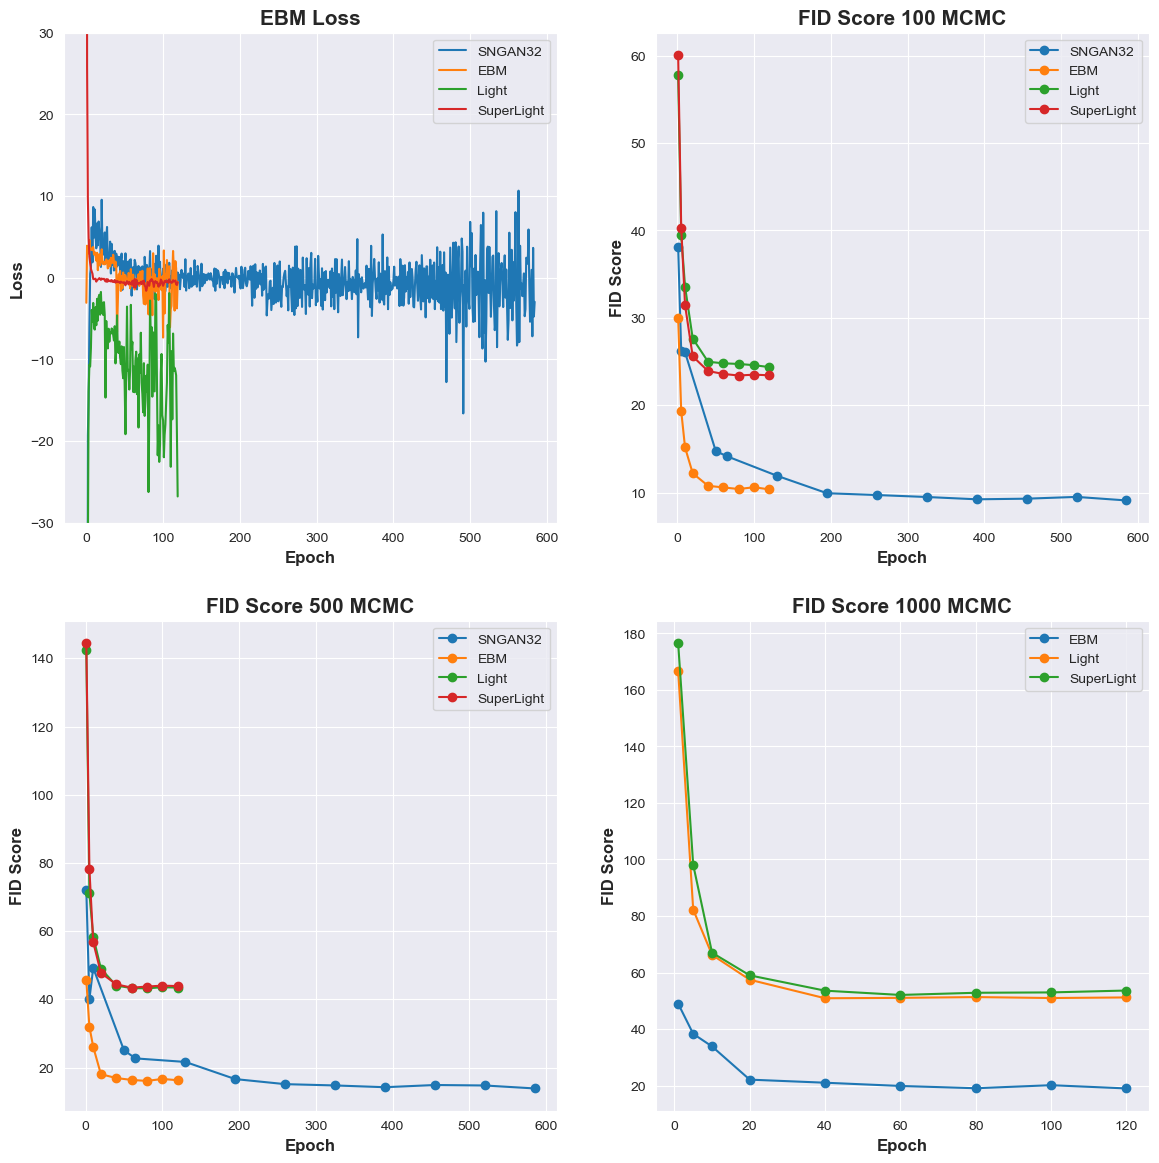

In [56]:
base_dir = '/Users/sunaybhat/Documents/GitHub/models'

dataset = 'cincic10_imagenet_subset'
EBMS = [['EBMSNGAN32','2023_12_22_07_47','SNGAN32'],
        ['EBM','2024_03_17_01_04','EBM'],
        ['LightEBM','2024_03_18_03_59','Light'],
        # ['LightEBM','2024_03_18_12_25','Light BS64'],
        ['SuperLightEBM','2024_03_18_04_00','SuperLight'],
        # ['SuperLightEBM','2024_03_18_11_51','SuperLight BS128'],
    ]

fig,axs = plt.subplots(2,2,figsize=(14,14))

for i,ebm in enumerate(EBMS):
    # Find all filepaths withs 'training_records' in the name
    records = [f for f in os.listdir(os.path.join(base_dir,ebm[0],dataset,ebm[1])) if 'training_record' in f]
    # Find the last epoch file
    last_epoch_file = max((file for file in records if 'epoch_' in file), key=lambda x: int(x.split('_')[-1].split('.')[0]))

    logs = torch.load(os.path.join(base_dir,ebm[0],dataset,ebm[1],last_epoch_file))

    axs[0,0].plot(logs['ebm_losses'],label=ebm[2])


    axs[0,1].plot(logs['fid_scores'][100].keys(),logs['fid_scores'][100].values(),'-o',label=ebm[2])


    axs[1,0].plot(logs['fid_scores'][500].keys(),logs['fid_scores'][500].values(),'-o',label=ebm[2])


    if 1000 in logs['fid_scores'].keys():
        axs[1,1].plot(logs['fid_scores'][1000].keys(),logs['fid_scores'][1000].values(),'-o',label=ebm[2])

axs[0,0].set_ylim(-30,30)
axs[0,0].set_title('EBM Loss',fontsize=15,fontweight='bold') 
axs[0,0].set_xlabel('Epoch',fontsize=12,fontweight='bold')
axs[0,0].set_ylabel('Loss',fontsize=12,fontweight='bold')
axs[0,0].legend(fontsize=10)

axs[0,1].set_title('FID Score 100 MCMC',fontsize=15,fontweight='bold')
axs[0,1].set_xlabel('Epoch',fontsize=12,fontweight='bold')
axs[0,1].set_ylabel('FID Score',fontsize=12,fontweight='bold')
axs[0,1].legend(fontsize=10)

axs[1,0].set_title('FID Score 500 MCMC',fontsize=15,fontweight='bold')
axs[1,0].set_xlabel('Epoch',fontsize=12,fontweight='bold')
axs[1,0].set_ylabel('FID Score',fontsize=12,fontweight='bold')
axs[1,0].legend(fontsize=10)

axs[1,1].set_title('FID Score 1000 MCMC',fontsize=15,fontweight='bold')
axs[1,1].set_xlabel('Epoch',fontsize=12,fontweight='bold')
axs[1,1].set_ylabel('FID Score',fontsize=12,fontweight='bold')
axs[1,1].legend(fontsize=10)

In [52]:
logs['fid_scores'].keys()

dict_keys([100, 500])

In [16]:
last_epoch_file

'training_record_epoch_120.pt'